# NDVI Calculation

In [2]:
import sys
sys.path.append('/work')


In [3]:
import datetime as dt
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import lithops
import time
import shutil
import os
import gc
import datetime
import math
import collections
from rasterio.io import MemoryFile
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from IPython import display

import cloudbutton_geospatial.s2froms3 as s2froms3
from cloudbutton_geospatial.utils import notebook as notebook_utils
from cloudbutton_geospatial.io_utils.ndvi import get_ndvi_params, ndvi_calculation, ndvi_tile_sentinel, get_subset_raster, lonlat_to_utm, get_poly_within
from cloudbutton_geospatial.io_utils.plot import tiff_overview, plot_map

%matplotlib inline

## Input parameters

Select the date interval in which tiles will be processed:

In [4]:
default_from = datetime.date(year=2024, month=9, day=27)
default_to = datetime.date(year=2024, month=9, day=30)

from_date, to_date = notebook_utils.pick_date_range(default_from, default_to)

DatePicker(value=datetime.date(2024, 9, 27), description='From day', step=1)

DatePicker(value=datetime.date(2024, 9, 30), description='To day', step=1)

Select the tile's cloud percentage threshold:

In [5]:
percentage = notebook_utils.pick_percentage_slider()

IntSlider(value=15, continuous_update=False, description='Percentage of cloudiness')

## Find tiles

Select the area which delimites the tiles you want to process (left click to mark a point in the map, right click to erase current selection):

In [6]:
map_region = notebook_utils.MapRegion(center=(39.60595289727246, -122.82804126978336))

Map(center=[39.60595289727246, -122.82804126978336], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [7]:
coords = []
lats = []
lons = []
points = []

for value in map_region.get_region()[:-1]:
    coords.append(value)
    lats.append(value[1])
    lons.append(value[0])

start_date = from_date.value  # Start date to search images
end_date = to_date.value  # End date to search images
what = ['B04', 'B08']  # What we want to download
cc = percentage.value  # Minimum cloud cover on each image, 25 is 25%

for lon, lat in zip(lons, lats):
    points.append([lon, lat])
    print([lon, lat], start_date, end_date, what, cc)

In [8]:
import math

def distance(origin, destination):
    lat1, lon1 = origin
    lat2, lon2 = destination
    radius = 6371  # km

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c

    return d

In [9]:
i, p = 0, 0

while i != len(points):
    p = i + 1
    while p != len(points):
        dis = distance(points[i], points[p])
        divisions = int(dis / 100)
        # If the zones are separated by more than 100 km, generate intermediate zones
        if divisions > 0:
            toSum = [(points[i][0] - points[p][0]) / (divisions + 1) , (points[i][1] - points[p][1]) / (divisions + 1)]
            while divisions != 0:
                point = points[i][0] - (toSum[0] * divisions)
                # Not add duplicated lons/lats
                if point not in lons:
                    lons.append(points[i][0] - (toSum[0] * divisions))
                    lats.append(points[i][1] - (toSum[1] * divisions))
                divisions = divisions - 1
        p = p + 1 
    i = i + 1

In [10]:
start_date = from_date.value  # Start date to search images
end_date = to_date.value  # End date to search images
what = ['B04', 'B08']  # What we want to download
cc = 80  # Minimum cloud cover on each image, 25 is 25% (15 by default)

In [11]:
cc

80

In [12]:
# Demonstration: Californa tile coords
cali_coords = [
    [38.510161585585045, -122.99194335937501],
    [36.071996052851325, -121.25610351562501],
    [36.96374622851412, -121.46484375000001],
    [37.575739257598414, -121.55273437500001],
    [39.15202827678992, -122.62939453125001],
    [39.703620879017976, -123.12377929687501],
    [36.74397383313428, -119.94873046875001],
    [38.472809653752314, -121.60766601562501]
]

## Get Sentinel-2 packages

In [13]:
scenes_f1 = []
scenes_f2 = []

# To use the demonstration tile coords, coment this line to use teh coords obtained from the map before
coords = cali_coords

for latency, longitude in coords:
    try:
        # Get scenes from intital date
        f1 = s2froms3.get_scene_list(lon=longitude, lat=latency, start_date=start_date, end_date=start_date,
        what=what, cloud_cover_le=cc)

        # Get scenes from end date
        f2 = s2froms3.get_scene_list(lon=longitude, lat=latency, start_date=end_date, end_date=end_date,
        what=what, cloud_cover_le=cc)

        # Not add duplicated scenes
        if len(scenes_f1) == 0 or f1 not in scenes_f1:
            scenes_f1.append(f1)
            scenes_f2.append(f2)
    except Exception:
        pass

if len(scenes_f1) == 0:
    raise Exception('No data found')

In [14]:
scene = scenes_f1[-1][-1]
scene

'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B08.tif'

In [15]:
scene_band = rasterio.open('s3://'+scene)
windows = list(scene_band.block_windows())

In [16]:
tile_band_keys = [tup for tup in scenes_f1]
flat_paths = [path for sublist in tile_band_keys for path in sublist]

In [17]:
# fexec = lithops.FunctionExecutor(
#     runtime_memory=1024,
#     log_level='INFO'
# )
# fexec.config['max_workers'] = 300

In [18]:
flat_paths

['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B08.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FF/2024/9/S2A_10SFF_20240927_0_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FF/2024/9/S2A_10SFF_20240927_0_L2A/B08.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FF/2024/9/S2A_10SFF_20240927_1_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FF/2024/9/S2A_10SFF_20240927_1_L2A/B08.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240927_0_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240927_0_L2A/B08.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_1_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_1_L2A/B08.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_0_L2A/B04.tif',
 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/K

In [19]:
!pip install nbformat


In [20]:
%run /work/wrapper-function.ipynb


In [21]:
print("🔍 Estimating memory and generating partitions for get_tile_meta (accurately per partition)...")

from collections import defaultdict
from dataplug.formats.geospatial.cog import CloudOptimizedGeoTiff, grid_partition_strategy

tiles_meta_inputs = []
uri_cache = {}

for uri in flat_paths:
    if uri not in uri_cache:
        est = estimate_chunk_size_local(uri)
        uri_cache[uri] = est
    else:
        est = uri_cache[uri]

    # print(f"- {uri}")
    # print(f"    → width: {est['width']}, height: {est['height']}, total_pixels: {est['total_pixels']}")
    # print(f"    → best_chunk: {est['best_chunk']}, runtime_memory: {est['runtime_memory']} MB\n")

    s3_config = get_s3_config()
    co = CloudObject.from_s3(CloudOptimizedGeoTiff, f"s3://{uri}", s3_config=s3_config)
    co.preprocess()
    parts = co.partition(grid_partition_strategy, n_splits=est["best_chunk"])

    # Optional refinement: estimate memory per partition based on size
    pixels_per_mb = 1_000_000
    for part in parts:
        pw = part.window.width
        ph = part.window.height
        part_pixels = pw * ph

        part_mem = ((part_pixels // pixels_per_mb) + 512)
        part_mem = min(max(512, (part_mem // 512) * 512), 8192)

        tiles_meta_inputs.append({
            "uri": uri,
            "window": part.window,
            "runtime_memory": part_mem
        })

# Group by memory
grouped_tiles_meta = defaultdict(list)
for entry in tiles_meta_inputs:
    grouped_tiles_meta[entry["runtime_memory"]].append(entry)

# Remote Lithops function
def get_tile_meta_single(input_data):
    import rasterio
    uri = input_data["uri"]
    win = input_data["window"]
    with rasterio.open("s3://" + uri) as src:
        x1, y1 = src.transform * (win.col_off, win.row_off)
        x2, y2 = src.transform * (win.col_off + win.width, win.row_off + win.height)
        return (uri, (x1, y1), (x2, y2))

# Run per memory group
tiles_meta = []
print("\n⚙️ Running get_tile_meta_single with per-partition memory optimization...")

for mem, group in grouped_tiles_meta.items():
    print(f"🚀 Running {len(group)} partitions with {mem}MB...")
    fexec = lithops.FunctionExecutor(runtime_memory=mem)
    fexec.config["log_level"] = "INFO"
    fexec.config["keep_alive"] = True

    wrapped = [{"input_data": g} for g in group]
    futures = fexec.map(get_tile_meta_single, wrapped)
    tiles_meta.extend(fexec.get_result(futures))

print("✅ Tile metadata extraction complete. Total partitions:", len(tiles_meta))


🔍 Estimating memory and generating partitions for get_tile_meta (accurately per partition)...

⚙️ Running get_tile_meta_single with per-partition memory optimization...
🚀 Running 504 partitions with 512MB...


2025-06-20 09:19:12,511 [INFO] config.py:146 -- Lithops v3.6.1.dev0 - Python3.10
2025-06-20 09:19:12,512 [DEBUG] config.py:107 -- Loading configuration from the cloud
2025-06-20 09:19:12,813 [DEBUG] config.py:186 -- Loading Serverless backend module: aws_lambda
2025-06-20 09:19:12,825 [DEBUG] config.py:226 -- Loading Storage backend module: aws_s3
2025-06-20 09:19:12,839 [DEBUG] aws_s3.py:36 -- Creating AWS S3 Client
2025-06-20 09:19:13,162 [INFO] aws_s3.py:59 -- S3 client created - Region: us-east-1
2025-06-20 09:19:13,214 [DEBUG] aws_lambda.py:53 -- Creating AWS Lambda client
2025-06-20 09:19:13,442 [INFO] aws_lambda.py:97 -- AWS Lambda client created - Region: us-east-1
2025-06-20 09:19:13,445 [DEBUG] invokers.py:105 -- ExecutorID 4f22f1-0 - Invoker initialized. Max workers: 1000
2025-06-20 09:19:13,447 [DEBUG] invokers.py:309 -- ExecutorID 4f22f1-0 - Serverless invoker created
2025-06-20 09:19:15,150 [DEBUG] executors.py:164 -- Function executor for aws_lambda created with ID: 4f22

✅ Tile metadata extraction complete. Total partitions: 504


In [22]:
tiles_meta

[('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (600000.0, 4000020.0),
  (618300.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (618300.0, 4000020.0),
  (636600.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (636600.0, 4000020.0),
  (654900.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (654900.0, 4000020.0),
  (673200.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (673200.0, 4000020.0),
  (691500.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (691500.0, 4000020.0),
  (709800.0, 3981720.0)),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (600000.0, 3981720.0),
  (618300.0, 3963420.0)),
 ('sentinel-cogs/sentinel-s

In [23]:
regions = [(tile_id, bound1, bound2,
            int(tile_id.split('/')[7].split('_')[1][:2]),
            True) for tile_id, bound1, bound2 in tiles_meta]

# notebook_utils.MapRegion(regions=regions, center=(38.141080, -122.126583), zoom=6)

In [24]:
regions

[('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (600000.0, 4000020.0),
  (618300.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (618300.0, 4000020.0),
  (636600.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (636600.0, 4000020.0),
  (654900.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (654900.0, 4000020.0),
  (673200.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (673200.0, 4000020.0),
  (691500.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
  (691500.0, 4000020.0),
  (709800.0, 3981720.0),
  10,
  True),
 ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio

def calculate_ndvi(scene, ij_window, storage):
    ij, window = ij_window
    band_4_s3_path = scene[0]  # Red band
    band_8_s3_path = scene[1]  # NIR band

    band_path_parts = band_4_s3_path.split('/')
    scene_id = band_path_parts[7]
    ndvi_filename = f'/tmp/{scene_id}_{ij}_NDVI.tif'
    ndvi_jpg_filename = f'/tmp/{scene_id}_{ij}_NDVI.jpg'

    # Open bands (Red and NIR)
    band4 = rasterio.open('s3://' + band_4_s3_path)
    band8 = rasterio.open('s3://' + band_8_s3_path)

    profile = band4.profile
    profile.update(dtype='float64', width=window.width, height=window.height)

    with rasterio.open(ndvi_filename, 'w', **profile) as dst:
        red = band4.read(1, window=window).astype('float64')
        nir = band8.read(1, window=window).astype('float64')
        with np.errstate(divide='ignore', invalid='ignore'):
            ndvi = np.where((nir + red) == 0, 0, (nir - red) / (nir + red)).astype('float64')
        ndvi_mean = np.mean(ndvi, axis=0)
        dst.write(ndvi, 1)

        # Set fixed scale for JPG visualization
        ndvi[0][0] = -1
        ndvi[0][1] = 1
        plt.imsave(ndvi_jpg_filename, ndvi, cmap="RdYlGn")

    with open(ndvi_jpg_filename, 'rb') as jpg_file:
        co_ndvi_jpg = storage.put_cloudobject(jpg_file.read(), key=ndvi_jpg_filename.replace('/tmp/', ''))

    return ndvi_filename, ndvi_mean, co_ndvi_jpg


def compute_ndvi_diff(old_scene, new_scene, ij_window, storage):
    ij, window = ij_window
    new_band_parts = new_scene[0].split('/')
    scene_id = new_band_parts[7]
    diff_jpg_filename = f'/tmp/{scene_id}_{ij}_NDVI_DIFF.jpg'
    result_key = old_scene[0].split('/')[7].rsplit('_', 3)[0]

    ndvi_file_old, ndvi_mean_old, co_ndvi_jpg_old = calculate_ndvi(old_scene, ij_window, storage)
    ndvi_file_new, ndvi_mean_new, co_ndvi_jpg_new = calculate_ndvi(new_scene, ij_window, storage)

    ndvi_old = rasterio.open(ndvi_file_old)
    ndvi_new = rasterio.open(ndvi_file_new)

    profile = ndvi_old.profile
    profile.update(dtype='float64', width=window.width, height=window.height)

    old_data = ndvi_old.read(1).astype('float64')
    new_data = ndvi_new.read(1).astype('float64')
    ndvi_diff = ((new_data - old_data) * (new_data + old_data)).astype('float64')

    # Set fixed scale for JPG visualization
    ndvi_diff[0][0] = -1
    ndvi_diff[0][1] = 1
    plt.imsave(diff_jpg_filename, ndvi_diff, cmap="RdYlGn")

    with open(diff_jpg_filename, 'rb') as diff_file:
        co_diff_jpg = storage.put_cloudobject(diff_file, key=diff_jpg_filename.replace('/tmp/', ''))

    return result_key, ij_window, co_ndvi_jpg_old, co_ndvi_jpg_new, co_diff_jpg


Using the selected parameters, get the identifiers of the selected tiles from Sentinel-2:

In [26]:
iterdata = []

for scene_f1, scene_f2 in zip(scenes_f1, scenes_f2):
    # Only process if both lists have at least one element
    if scene_f1 and scene_f2:
        for window in windows:
            iterdata.append((scene_f1, scene_f2, window))

iterdata


[(['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
   'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B08.tif'],
  ['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240930_0_L2A/B04.tif',
   'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240930_0_L2A/B08.tif'],
  ((0, 0), Window(col_off=0, row_off=0, width=1024, height=1024))),
 (['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
   'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B08.tif'],
  ['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240930_0_L2A/B04.tif',
   'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240930_0_L2A/B08.tif'],
  ((0, 1), Window(col_off=1024, row_off=0, width=1024, height=1024))),
 (['sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2A_10SFE_20240927_0_L2A/B04.tif',
   'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FE/2024/9/S2

In [27]:
print("🔍 Rebuilding iterdata using co.partition and estimating memory per chunk (no redundancy)...")

s3_config = get_s3_config()
uri_cache = {}
est_cache = {}
partitioned_ndvi = []

# Step 1: Deduplicate by unique tile pairs (t1, t2)
unique_pairs = set((tuple(t1), tuple(t2)) for t1, t2, _ in iterdata)
print(unique_pairs)
# Step 2: Estimate + partition once per unique t1 file
for t1_tuple, t2_tuple in unique_pairs:
    t1 = list(t1_tuple)
    t2 = list(t2_tuple)

    if not t1 or not t2:
        continue

    uri = t1[0]

    # Estimate chunk size if not done
    if uri not in est_cache:
        est_cache[uri] = estimate_chunk_size_local(uri)
    est = est_cache[uri]
    best_chunk = est["best_chunk"]

    # Load CloudObject once
    if uri not in uri_cache:
        co = CloudObject.from_s3(CloudOptimizedGeoTiff, f"s3://{uri}", s3_config=s3_config)
        co.preprocess(force=True)
        uri_cache[uri] = co
    else:
        co = uri_cache[uri]

    # Partition using estimated best_chunk
    parts = co.partition(grid_partition_strategy, n_splits=best_chunk)

    import math

    num_parts = len(parts)
    # Estimate square-ish grid (you can replace this logic if you use fixed chunk size)
    num_cols = math.ceil(math.sqrt(num_parts))

    for ij, part in enumerate(parts):
        row = ij // num_cols
        col = ij % num_cols

        width, height = part.window.width, part.window.height
        total_pixels = width * height
        pixels_per_mb = 1_000_000
        mem = ((total_pixels // pixels_per_mb) + 512)
        mem = min(max(512, (mem // 512) * 512), 8192)

        partitioned_ndvi.append({
            "input_data": (t1, t2, ((row, col), part.window)),
            "runtime_memory": mem
        })

        print(f"- {uri} | part ({row},{col}) → {mem} MB for {width}x{height} | total_parts: {num_parts}")



# Step 3: Group by memory size
from collections import defaultdict
grouped = defaultdict(list)
for task in partitioned_ndvi:
    grouped[task["runtime_memory"]].append(task["input_data"])

# Step 4: Lithops dispatch
print("\n⚙️ Running compute_ndvi_diff using partitioned tiles and grouped memory...")
results = []

for mem, batch in grouped.items():
    print(f"🚀 Running {len(batch)} partitions with {mem}MB...")
    fexec = lithops.FunctionExecutor(runtime_memory=mem)
    fexec.config["log_level"] = "INFO"
    fexec.config["keep_alive"] = True
    fs = fexec.map(compute_ndvi_diff, batch)
    results.extend(fexec.get_result(fs))

print("✅ NDVI diff (partitioned) complete. Total partitions:", len(results))


🔍 Rebuilding iterdata using co.partition and estimating memory per chunk (no redundancy)...
{(('sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_1_L2A/B04.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_1_L2A/B08.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_0_L2A/B04.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240927_0_L2A/B08.tif'), ('sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240930_0_L2A/B04.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/11/S/KA/2024/9/S2A_11SKA_20240930_0_L2A/B08.tif')), (('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240927_0_L2A/B04.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240927_0_L2A/B08.tif'), ('sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240930_1_L2A/B04.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FG/2024/9/S2A_10SFG_20240930_1_L2A/B08.tif', 'sentinel-cogs/sentinel-s2-l2a-cogs/1

2025-06-20 09:19:49,319 [INFO] config.py:146 -- Lithops v3.6.1.dev0 - Python3.10
2025-06-20 09:19:49,320 [DEBUG] config.py:107 -- Loading configuration from the cloud


- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,0) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,1) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,2) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,3) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,4) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (0,5) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2-l2a-cogs/10/S/FH/2024/9/S2A_10SFH_20240927_0_L2A/B04.tif | part (1,0) → 512 MB for 1830x1830 | total_parts: 36
- sentinel-cogs/sentinel-s2

2025-06-20 09:19:49,630 [DEBUG] config.py:186 -- Loading Serverless backend module: aws_lambda
2025-06-20 09:19:49,641 [DEBUG] config.py:226 -- Loading Storage backend module: aws_s3
2025-06-20 09:19:49,650 [DEBUG] aws_s3.py:36 -- Creating AWS S3 Client
2025-06-20 09:19:49,914 [INFO] aws_s3.py:59 -- S3 client created - Region: us-east-1
2025-06-20 09:19:49,966 [DEBUG] aws_lambda.py:53 -- Creating AWS Lambda client
2025-06-20 09:19:50,415 [INFO] aws_lambda.py:97 -- AWS Lambda client created - Region: us-east-1
2025-06-20 09:19:50,420 [DEBUG] invokers.py:105 -- ExecutorID 4f22f1-1 - Invoker initialized. Max workers: 1000
2025-06-20 09:19:50,422 [DEBUG] invokers.py:309 -- ExecutorID 4f22f1-1 - Serverless invoker created
2025-06-20 09:19:50,568 [DEBUG] executors.py:164 -- Function executor for aws_lambda created with ID: 4f22f1-1
2025-06-20 09:19:50,570 [INFO] invokers.py:119 -- ExecutorID 4f22f1-1 | JobID M000 - Selected Runtime: runtime-c2a280ba-8a05-4465-ac20-f8b77e0e377c:17a8db77-cf4e-

✅ NDVI diff (partitioned) complete. Total partitions: 180


In [28]:
grouped_results = collections.defaultdict(list)

for res in results:
    key, ij_window, co_jpg_f1, co_jpg_f2, co_jpg_diff = res
    grouped_results[key].append((ij_window, co_jpg_f1, co_jpg_f2, co_jpg_diff))

In [29]:
grouped_results.keys()

dict_keys(['S2A_11SKA', 'S2A_10SFG', 'S2A_10SFF', 'S2A_10SFE', 'S2A_10SFH'])

## Get and plot the computed jpg diff tile image

In [30]:
def get_jpg(data):
    if not data:
        print("Data is empty! Skipping this case...")
        return None  # Avoid proceeding if data is empty

    file_name = '_'.join(data[0][1].key.split('_')[:5])
    
    if 'DIFF' in data[0][1].key:
        output_file = f'AwsData/{file_name}_NDVI_DIFF.jpg'
    else:
        output_file = f'AwsData/{file_name}_NDVI.jpg'
        
    jpg_tiles = {}

    def load_tile(data):
        ij_window, co_jpg = data
        row = ij_window[0][0]
        col = ij_window[0][1]
        jpg_stream = fexec.storage.get_cloudobject(co_jpg, stream=True)

        if row not in jpg_tiles:
            jpg_tiles[row] = [None] * 11

        jpg_tiles[row][col] = Image.open(jpg_stream)

    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = list(executor.map(load_tile, data))

    composite_image = Image.new('RGB', (scene_band.width, scene_band.height))

    x_offset = 0
    y_offset = 0

    for row in sorted(jpg_tiles.keys()):
        row_imgs = jpg_tiles[row]
        for img in row_imgs:
            if img is None:
                continue
            composite_image.paste(img, (x_offset, y_offset))
            x_offset += img.size[0]
        x_offset = 0
        if any(img is not None for img in row_imgs):
            y_offset += row_imgs[0].size[1]  # Use first non-None img for height

        
    thumbnail_size = (640, 640)
    composite_image.thumbnail(thumbnail_size)

    images[output_file] = composite_image
    return output_file  # Return filename to confirm successful generation


In [31]:
grouped_results

defaultdict(list,
            {'S2A_11SKA': [(((0, 0),
                Window(col_off=0, row_off=0, width=1830, height=1830)),
               <lithops.storage.utils.CloudObject at 0x7af2cc409450>),
              (((0, 1),
                Window(col_off=1830, row_off=0, width=1830, height=1830)),
               <lithops.storage.utils.CloudObject at 0x7af2cc40ae90>),
              (((0, 2),
                Window(col_off=3660, row_off=0, width=1830, height=1830)),
               <lithops.storage.utils.CloudObject at 0x7af2cf272b00>),
              (((0, 3),
                Window(col_off=5490, row_off=0, width=1830, height=1830)),
               <lithops.storage.utils.CloudObject at 0x7af2cf5ffcd0>),
              (((0, 4),
                Window(col_off=7320, row_off=0, width=1830, height=1830)),
               <lithops.storage.utils.CloudObject at 0x7af2cc408190>),
              (((0, 5),
                Window(col_off=9150, row_off=0, width=1830, height=1830)),
               <lithops

In [32]:
# Choose the correct key from the available ones
zone_key = 'S2A_10SFE'

if zone_key in grouped_results:
    group = grouped_results[zone_key]

    co_jpgs_f1 = [(name, f1) for name, f1, f2, diff in group]
    co_jpgs_f2 = [(name, f2) for name, f1, f2, diff in group]
    co_jpgs_diff = [(name, diff) for name, f1, f2, diff in group]

    # Display the lists if needed
    print("F1:", co_jpgs_f1)
    print("F2:", co_jpgs_f2)
    print("Diff:", co_jpgs_diff)
else:
    print(f"The key '{zone_key}' is not in grouped_results. Available keys: {list(grouped_results.keys())}")


F1: [(((0, 0), Window(col_off=0, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf272ad0>), (((0, 1), Window(col_off=1830, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf813460>), (((0, 2), Window(col_off=3660, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf692c20>), (((0, 3), Window(col_off=5490, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf693220>), (((0, 4), Window(col_off=7320, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf811a20>), (((0, 5), Window(col_off=9150, row_off=0, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cf693190>), (((1, 0), Window(col_off=0, row_off=1830, width=1830, height=1830)), <lithops.storage.utils.CloudObject object at 0x7af2cc40b6d0>), (((1, 1), Window(col_off=1830, row_off=1830, width=1830, height=1830)), <l

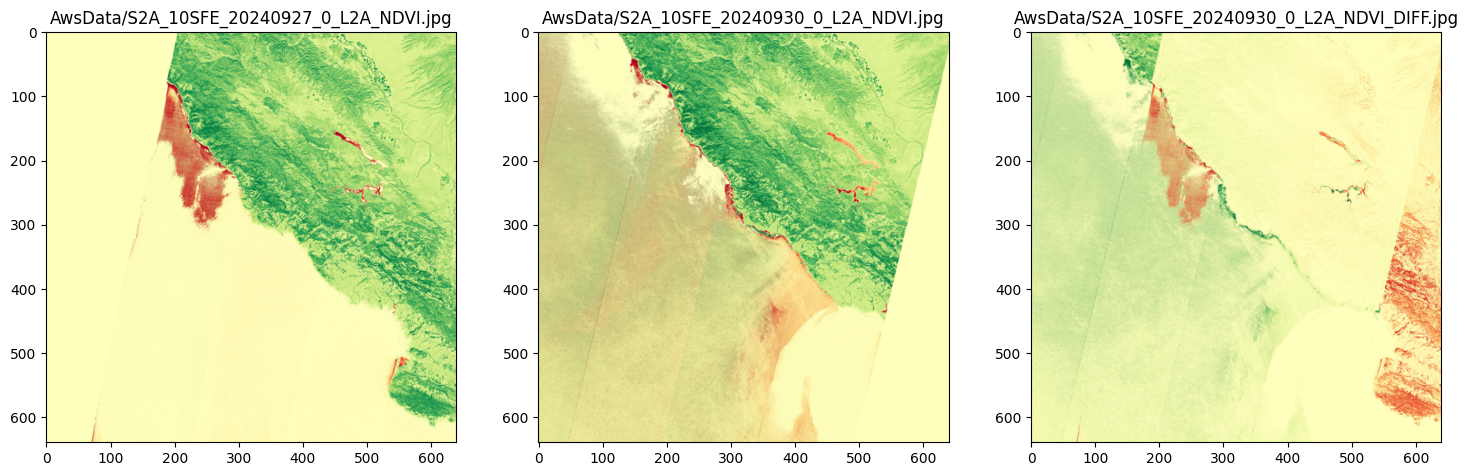

In [33]:
images = {}
with ThreadPoolExecutor(max_workers=2) as ex:
    fs = list(ex.map(get_jpg, [co_jpgs_f1, co_jpgs_f2, co_jpgs_diff]))

f, ax = plt.subplots(1,3, figsize=(18, 18))
i = 0
for j in sorted(images.keys()):
    ax[i].set_title(j)
    ax[i].imshow(images[j])
    i = i+1
plt.show()

## KPIs

In [34]:
import boto3

s3client = boto3.client('s3')
total_sz = 0

for scenes in [scenes_f1, scenes_f2]:
    for scene in scenes:
        # Ensure 'scene' is actually a list or tuple of paths
        if isinstance(scene, list) or isinstance(scene, tuple):
            for band_path in scene:
                if isinstance(band_path, str) and '/' in band_path:
                    bucket, key = band_path.split('/', 1)
                    meta = s3client.head_object(Bucket=bucket, Key=key)
                    total_sz += int(meta['ResponseMetadata']['HTTPHeaders']['content-length'])

# Assuming you already have the execution statistics
stats = [f.stats for f in fexec.futures if hasattr(f, 'stats') and 'worker_func_exec_time' in f.stats]
mean_exec_time = np.mean([stat['worker_func_exec_time'] for stat in stats])
throughput = (total_sz / 1_000_000_000) / mean_exec_time

print(f"Throughput: {throughput:.4f} GB/s")


Throughput: 0.2537 GB/s


In [35]:
print(f'Procesed {round(total_sz / 1_000_000_000, 2)} GB in {round(mean_exec_time, 2)} s => {round(throughput, 2)} GB/s')

Procesed 3.74 GB in 14.75 s => 0.25 GB/s


In [36]:
gbxms_price = 0.0000000167
sum_total_time = sum([stat['worker_exec_time'] for stat in stats]) * 1000
price = gbxms_price * sum_total_time * 1  # Price GB/ms * sum of times in ms * 1 GB

In [37]:
print(f'Experiment total price is {round(price, 3)} USD')

Experiment total price is 0.069 USD
